Saving shepplogan.png to shepplogan (18).png


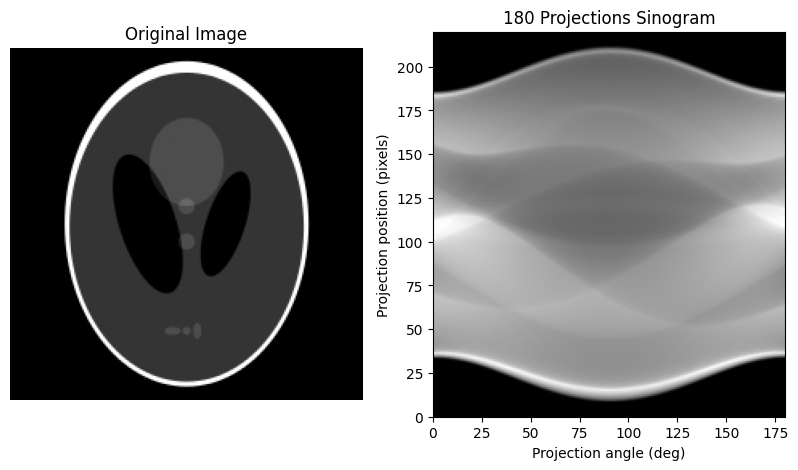

FBP MSE: 0.00806
FBP RMSE: 0.0898
FBP PSNR: 20.9
FBP SSIM: 0.837


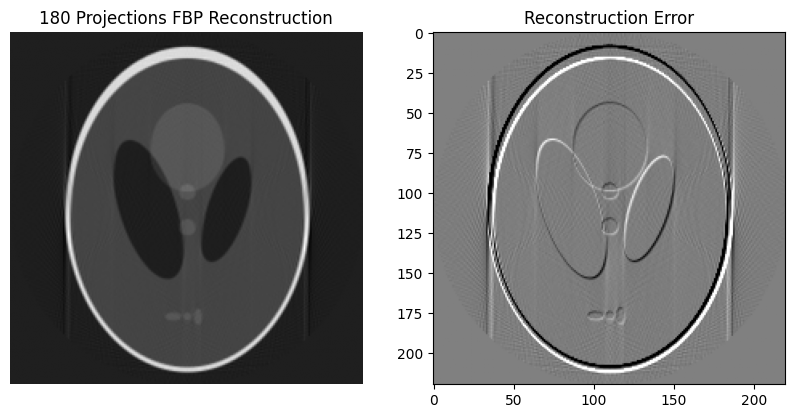

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.transform import rotate, resize
from google.colab import files
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

# ----------------------------
# 1. Radon Transform
# ----------------------------
def radon_transform(image, steps):
    """Compute sinogram of the image."""
    n = image.shape[0]
    sinogram = np.zeros((n, steps), dtype=np.float64)
    for s in range(steps):
        rotated = rotate(image, -s * 180 / steps, resize=False, order=1, mode='constant')
        sinogram[:, s] = np.sum(rotated, axis=0)
    return sinogram

# ----------------------------
# 2. Pad Sinogram to Square
# ----------------------------
def sinogram_circle_to_square(sinogram):
    diagonal = int(np.ceil(np.sqrt(2) * sinogram.shape[0]))
    pad = diagonal - sinogram.shape[0]
    old_center = sinogram.shape[0] // 2
    new_center = diagonal // 2
    pad_before = new_center - old_center
    pad_width = ((pad_before, pad - pad_before), (0, 0))
    return np.pad(sinogram, pad_width, mode='constant', constant_values=0)

# ----------------------------
# 3. Filtered Backprojection
# ----------------------------
def iradon_transform(radon_image, theta, interpolation='linear'):
    output_size = radon_image.shape[0]
    radon_image = sinogram_circle_to_square(radon_image)
    th = np.deg2rad(theta)  # convert to radians

    # pad to next power of 2 for FFT
    proj_size_padded = max(64, int(2 ** np.ceil(np.log2(2 * radon_image.shape[0]))))
    pad_width = ((0, proj_size_padded - radon_image.shape[0]), (0, 0))
    img = np.pad(radon_image, pad_width, mode='constant', constant_values=0)

    # Fourier filtering (ramp filter)
    freqs = np.fft.fftfreq(proj_size_padded).reshape(-1, 1)
    ramp_filter = 2 * np.abs(freqs)
    projection_fft = np.fft.fft(img, axis=0) * ramp_filter
    radon_filtered = np.real(np.fft.ifft(projection_fft, axis=0))
    radon_filtered = radon_filtered[:radon_image.shape[0], :]

    # Backprojection
    reconstructed = np.zeros((output_size, output_size), dtype=np.float64)
    X, Y = np.mgrid[0:output_size, 0:output_size]
    xpr = X - output_size // 2
    ypr = Y - output_size // 2
    mid_index = radon_image.shape[0] // 2

    for i in range(len(theta)):
        t = ypr * np.cos(th[i]) - xpr * np.sin(th[i])
        x = np.arange(radon_filtered.shape[0]) - mid_index

        if interpolation == 'linear':
            backproj = np.interp(t, x, radon_filtered[:, i], left=0, right=0)
        else:
            from scipy.interpolate import interp1d
            interpolant = interp1d(x, radon_filtered[:, i], kind=interpolation,
                                   bounds_error=False, fill_value=0)
            backproj = interpolant(t)
        reconstructed += backproj

    # Mask outside circle
    radius = output_size // 2
    mask = (xpr**2 + ypr**2) <= radius**2
    reconstructed[~mask] = 0

    # Normalize
    return reconstructed * np.pi / (2 * len(th))

# ----------------------------
# 4. Main
# ----------------------------
# Load image
uploaded = files.upload()
imagename = next(iter(uploaded)) # Get the filename from the dictionary
image = imread(imagename)
if image.ndim == 3:
    if image.shape[2] == 4: # Check if it's RGBA
        image = image[:, :, :3] # Discard alpha channel
    image = rgb2gray(image)
image = resize(image, (220, 220), anti_aliasing=True)

# Radon Transform
steps = 180
sinogram = radon_transform(image, steps)

# Theta angles
theta = np.linspace(0., 180., steps, endpoint=False)

# FBP reconstruction
reconstruction_fbp = iradon_transform(sinogram, theta, interpolation='cubic')

# ----------------------------
# 5. Plot results
# ----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.set_title("Original Image")
ax1.imshow(image, cmap='gray')
ax1.axis('off')

ax2.set_title("180 Projections Sinogram")
ax2.imshow(sinogram, cmap='gray', aspect='auto',
           extent=(0, 180, 0, sinogram.shape[0]))
ax2.set_xlabel("Projection angle (deg)")
ax2.set_ylabel("Projection position (pixels)")

plt.show()

# Reconstruction error
error = reconstruction_fbp - image

# Calculate and print metrics
mse = np.mean(error**2)
rmse = np.sqrt(mse)

# PSNR calculation requires `data_range` for the image. Assuming normalized image [0, 1].
# If image pixel values are 0-255, data_range should be 255.
data_range = image.max() - image.min() # For float images normalized to [0,1]
psnr_value = psnr(image, reconstruction_fbp, data_range=data_range)

# SSIM calculation. Requires 'data_range' and can take 'win_size' for window size.
# Also multi-channel option is for color images, which we are not using here.
ssim_value = ssim(image, reconstruction_fbp, data_range=data_range)

print(f'FBP MSE: {mse:.3g}')
print(f'FBP RMSE: {rmse:.3g}')
print(f'FBP PSNR: {psnr_value:.3g}')
print(f'FBP SSIM: {ssim_value:.3g}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.set_title("180 Projections FBP Reconstruction")
ax1.imshow(reconstruction_fbp, cmap='gray')
ax1.axis('off')

ax2.set_title("Reconstruction Error")
imkwargs = dict(vmin=-0.2, vmax=0.2)
ax2.imshow(error, cmap='gray', **imkwargs)
plt.show()